In [ ]:
# PyTorch MLP on MNIST with a custom training loop

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Data
# ToTensor() scales to [0,1]; Normalize uses mean/std for MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # per-channel mean, std for MNIST
])

train_dataset = datasets.MNIST(root=".", train=True, transform=transform, download=True)
test_dataset  = datasets.MNIST(root=".", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# Model
class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),  # (B, 1, 28, 28) -> (B, 784)
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # logits (no softmax)
        )

    def forward(self, x):
        return self.net(x)

model = MLP().to(device)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss() # expects logits + class indices
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Accuracy helper
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    return (preds == targets).float().mean().item()

# Train/Eval loops
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, running_acc, n_batches = 0.0, 0.0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        # Forward
        logits = model(images)
        loss = criterion(logits, labels)

        # Backward
        optimizer.zero_grad(set_to_none=True)  # faster, avoids some memory overhead
        loss.backward()
        optimizer.step()

        # Metrics
        acc = accuracy_from_logits(logits, labels)
        running_loss += loss.item()
        running_acc  += acc
        n_batches    += 1

    return running_loss / n_batches, running_acc / n_batches

@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, running_acc, n_batches = 0.0, 0.0, 0

    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, labels)
        acc = accuracy_from_logits(logits, labels)

        running_loss += loss.item()
        running_acc  += acc
        n_batches    += 1

    return running_loss / n_batches, running_acc / n_batches

# Training driver
EPOCHS = 5
train_hist, val_hist = {"loss": [], "acc": []}, {"loss": [], "acc": []}

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    va_loss, va_acc = evaluate(model, test_loader, criterion, device)  # using test as val for simplicity

    train_hist["loss"].append(tr_loss)
    train_hist["acc"].append(tr_acc)
    val_hist["loss"].append(va_loss)
    val_hist["acc"].append(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
          f"val_loss={va_loss:.4f} acc={va_acc:.4f}")

# Save model
torch.save(model.state_dict(), "mnist_mlp.pt")
print("Saved model to mnist_mlp.pt")

Using device: cpu


100.0%
100.0%
100.0%
100.0%
c:\Users\shurai\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\data\dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 01 | train_loss=0.2782 acc=0.9160 | val_loss=0.1150 acc=0.9653
Epoch 02 | train_loss=0.1357 acc=0.9590 | val_loss=0.1137 acc=0.9657
Epoch 03 | train_loss=0.1050 acc=0.9676 | val_loss=0.0901 acc=0.9729
Epoch 04 | train_loss=0.0901 acc=0.9718 | val_loss=0.0809 acc=0.9749
Epoch 05 | train_loss=0.0784 acc=0.9750 | val_loss=0.0703 acc=0.9777
Saved model to mnist_mlp.pt


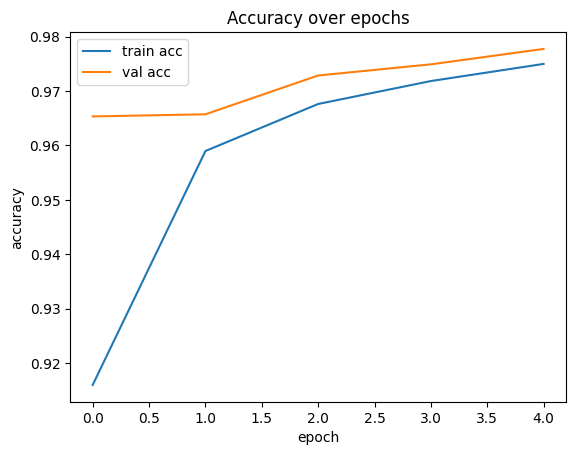

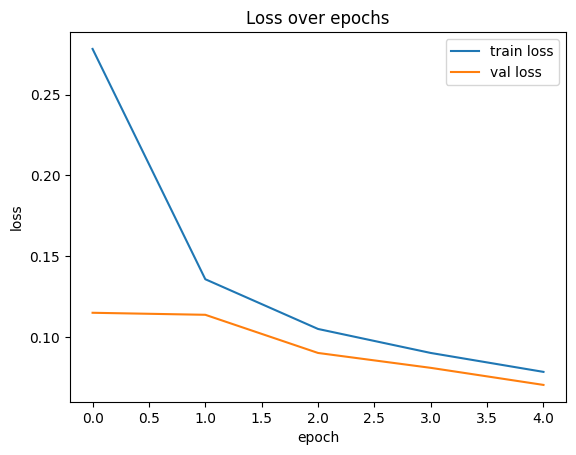

In [3]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_hist["acc"], label="train acc")
plt.plot(val_hist["acc"], label="val acc")
plt.title("Accuracy over epochs")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.show()

plt.figure()
plt.plot(train_hist["loss"], label="train loss")
plt.plot(val_hist["loss"], label="val loss")
plt.title("Loss over epochs")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend()
plt.show()

## Further hands on practice
1. **Change architecture**
   - Try hidden_sizes = [512, 256] or [256] only.
   - Observe training vs validation accuracy.
2. **Replace Adam with SGD** and compare speed and accuracy.
    ```python
    optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.9)
    ```
3. **Add Weight Decay (L2)**: Contrast with no weight decay.
    ```python
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ```
4. **Batch Size Sensitivity**
   - Try batch_size=32, 128, 512.
   - Note effects on stability and speed.
5. Compute Confusion Matrix
    ```python
    import itertools
    import matplotlib.pyplot as plt
    import numpy as np
    from sklearn.metrics import confusion_matrix

    @torch.no_grad()
    def get_all_preds_targets(model, loader, device):
        model.eval()
        all_preds, all_targets = [], []
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            preds = logits.argmax(1)
            all_preds.append(preds.cpu())
            all_targets.append(y.cpu())
        return torch.cat(all_preds), torch.cat(all_targets)

    preds, targs = get_all_preds_targets(model, test_loader, device)
    cm = confusion_matrix(targs.numpy(), preds.numpy())
    print(cm)
    ```



